### Single Layer Neuron

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Sequential
from tensorflow.keras.losses import MeanSquaredError, BinaryCrossentropy
from tensorflow.keras.activations import sigmoid
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [16]:
print(tf.__version__)

2.21.0


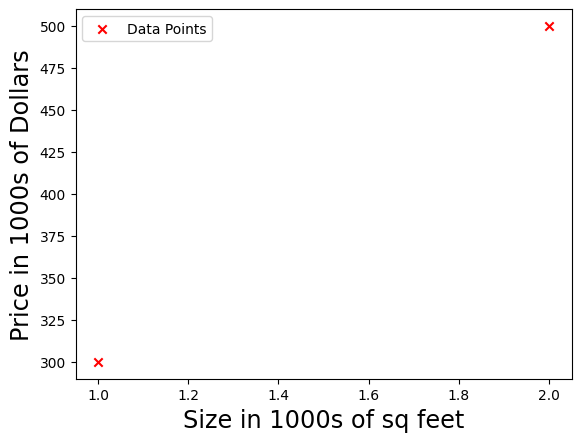

In [22]:
X_train = np.array([[1.0], [2.0]], dtype=np.float32)           #(size in 1000 square feet)
Y_train = np.array([[300.0], [500.0]], dtype=np.float32) 

fig, ax = plt.subplots(1,1)
ax.scatter(X_train,Y_train, color = 'red', marker = "x", label="Data Points")
ax.set_xlabel("Size in 1000s of sq feet", fontsize = 'xx-large')
ax.set_ylabel("Price in 1000s of Dollars", fontsize = 'xx-large')
ax.legend()
plt.show()

In [18]:
# Define a single layer

linear_layer  = tf.keras.layers.Dense(units = 1, activation= 'linear')
print(linear_layer)

<Dense name=dense_1, built=False>


In [19]:
# Display weights, empty right now as we have not instantiated

linear_layer.get_weights()

[]

In [25]:
a1 = linear_layer(X_train[0].reshape(1,1))
print(a1)

tf.Tensor([[0.2518444]], shape=(1, 1), dtype=float32)


In [26]:
w,b = linear_layer.get_weights()
print(f"w = {w}, b = {b}")

w = [[0.2518444]], b = [0.]


In [27]:
set_w = np.array([[200]])
set_b = np.array([100])

linear_layer.set_weights([set_w, set_b])
print(linear_layer.get_weights())

[array([[200.]], dtype=float32), array([100.], dtype=float32)]


In [28]:
a1 = linear_layer(X_train[0].reshape(1,1))
print(a1)

alin = np.dot(set_w,X_train[0].reshape(1,1)) + set_b
print(alin)

tf.Tensor([[300.]], shape=(1, 1), dtype=float32)
[[300.]]


In [30]:
prediction_tf = linear_layer(X_train)
prediction_np = np.dot( X_train, set_w) + set_b

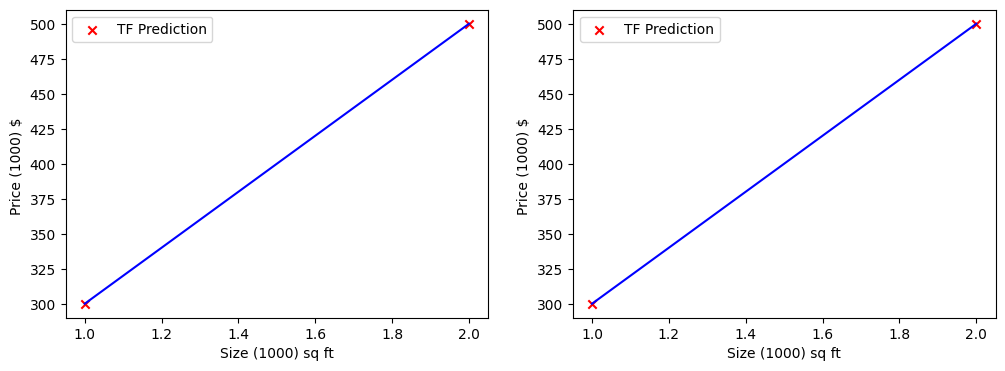

In [45]:
fig, ax = plt.subplots(1,2, figsize = (12,4))
ax[0].scatter(X_train, Y_train, marker = "x", color = 'r', label = "TF Prediction")
ax[0].plot(X_train, prediction_tf, color = 'b')
ax[0].set_xlabel("Size (1000) sq ft")
ax[0].set_ylabel("Price (1000) $ ")
ax[0].legend()

ax[1].scatter(X_train, Y_train, marker = "x", color = 'r', label = "TF Prediction")
ax[1].plot(X_train, prediction_np, color = 'b')
ax[1].set_xlabel("Size (1000) sq ft")
ax[1].set_ylabel("Price (1000) $ ")
ax[1].legend()
plt.show()

### Neuron with sigmoid activation

In [ ]:
# Neuron with sigmoid Activation

X_train = np.array([0., 1, 2, 3, 4, 5], dtype=np.float32).reshape(-1,1)  # 2-D Matrix
Y_train = np.array([0,  0, 0, 1, 1, 1], dtype=np.float32).reshape(-1,1)  # 2-D Matrix

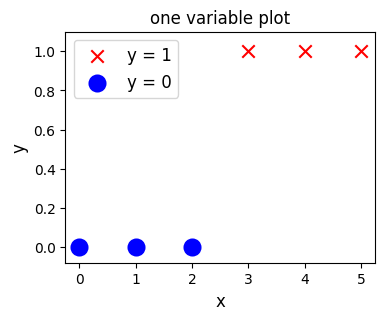

In [51]:
pos = Y_train == 1
neg = Y_train == 0

fig, ax = plt.subplots(1,1,figsize = (4,3))
ax.scatter(X_train[pos], Y_train[pos], marker = 'x', c = 'r', s = 80, label = 'y = 1')
ax.scatter(X_train[neg], Y_train[neg], marker = 'o', c = 'b', s = 100, label = 'y = 0', lw = 3)

ax.set_ylim(-0.08,1.1)
ax.set_ylabel('y', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.set_title('one variable plot')
ax.legend(fontsize=12)
plt.show()

In [52]:
model = Sequential(
    [
        tf.keras.layers.Dense(1, input_dim = 1, activation= 'sigmoid', name = 'L1')
    ]
)

d:\Study_Resources\Machine Learning Specialization\Coursera\Coursera_Machine_Learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [55]:
logistic_layer = model.get_layer('L1')
w,b = logistic_layer.get_weights()
print(w,b)
print(w.shape, b.shape)

[[-0.9584633]] [0.]
(1, 1) (1,)


In [56]:
set_w = np.array([[2]])
set_b = np.array([-4.5])
logistic_layer.set_weights([set_w, set_b])
print(logistic_layer.get_weights())

[array([[2.]], dtype=float32), array([-4.5], dtype=float32)]


In [58]:
def sigmoid(z):
    return 1/(1 + np.exp(-1 * z))
    

In [59]:
a1 = model.predict(X_train[0].reshape(1,1))
print(a1)
alog = sigmoid(np.dot(set_w,X_train[0].reshape(1,1)) + set_b)
print(alog)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[0.01098694]]
[[0.01098694]]


In [60]:
import numpy as np
import matplotlib.pyplot as plt

def plot_logistic(x_train, y_train, model, set_w, set_b):
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # Create grid
    x_vals = np.linspace(0, 5, 100)
    y_vals = np.linspace(0, 1, 100)
    xx, yy = np.meshgrid(x_vals, y_vals)

    # Flatten grid for prediction
    grid = xx.reshape(-1, 1)

    # 🔹 TensorFlow prediction
    z_tf = model.predict(grid, verbose=0)
    z_tf = z_tf.reshape(xx.shape)

    # 🔹 NumPy prediction
    z_np = 1 / (1 + np.exp(-(np.dot(grid, set_w) + set_b)))
    z_np = z_np.reshape(xx.shape)

    # ===== Plot 1: TensorFlow =====
    ax[0].contourf(xx, yy, z_tf, levels=50, cmap="Blues")
    ax[0].scatter(x_train[y_train[:,0]==1], y_train[y_train[:,0]==1],
                  marker='x', color='r', label='y=1')
    ax[0].scatter(x_train[y_train[:,0]==0], y_train[y_train[:,0]==0],
                  marker='o', facecolors='none', edgecolors='b', label='y=0')
    ax[0].set_title("TensorFlow Model")
    ax[0].set_xlabel("X")
    ax[0].set_ylabel("Y")
    ax[0].legend()

    # ===== Plot 2: NumPy =====
    ax[1].contourf(xx, yy, z_np, levels=50, cmap="Blues")
    ax[1].scatter(x_train[y_train[:,0]==1], y_train[y_train[:,0]==1],
                  marker='x', color='r', label='y=1')
    ax[1].scatter(x_train[y_train[:,0]==0], y_train[y_train[:,0]==0],
                  marker='o', facecolors='none', edgecolors='b', label='y=0')
    ax[1].set_title("NumPy Model")
    ax[1].set_xlabel("X")
    ax[1].set_ylabel("Y")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

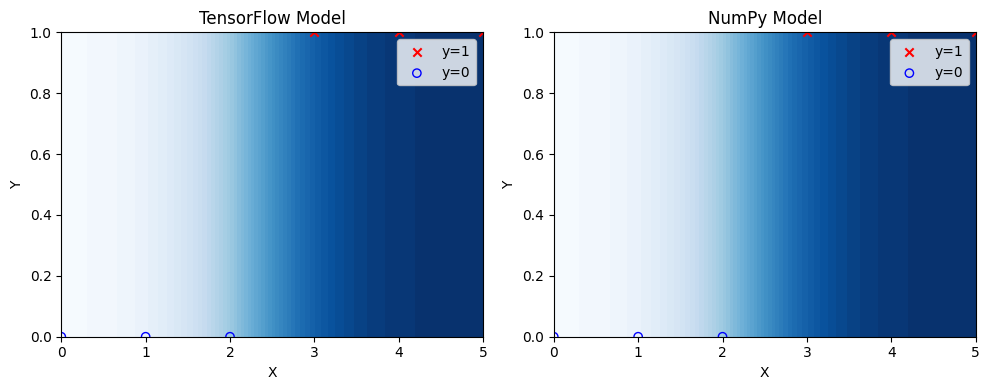

In [64]:
plot_logistic(X_train, Y_train, model, set_w, set_b)